# SPY Market Regime Clustering and LSTM Forecasting

This notebook executes the same modular pipeline used by the command-line project. It demonstrates K-Means Clustering, chronological time-series validation, baseline models, and a PyTorch LSTM.

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'run_pipeline.py').exists():
    raise RuntimeError(f'Run this notebook from the project directory or notebooks directory: {PROJECT_ROOT}')
sys.path.insert(0, str(PROJECT_ROOT))
PROJECT_ROOT

WindowsPath('C:/Users/harsh/OneDrive/Documents/GitHub/systematic-trading-market-research/quant-research/spy-market-regime-clustering-lstm')

In [2]:
from run_pipeline import run_pipeline

result = run_pipeline(project_root=PROJECT_ROOT, max_epochs=100)
result

{'selected_k': 2,
 'metrics_path': 'C:\\Users\\harsh\\OneDrive\\Documents\\GitHub\\systematic-trading-market-research\\quant-research\\spy-market-regime-clustering-lstm\\outputs\\metrics.json',
 'report_path': 'C:\\Users\\harsh\\OneDrive\\Documents\\GitHub\\systematic-trading-market-research\\research-papers\\2026-06-30-spy-market-regime-clustering-lstm-report.md',
 'epochs_trained': 18}

In [3]:
metrics = json.loads((PROJECT_ROOT / 'outputs' / 'metrics.json').read_text())
{name: {metric: round(values[metric], 3) for metric in ['accuracy', 'balanced_accuracy', 'macro_f1']} for name, values in metrics['models'].items()}

{'logistic_regression': {'accuracy': 0.94,
  'balanced_accuracy': 0.917,
  'macro_f1': 0.913},
 'lstm': {'accuracy': 0.936, 'balanced_accuracy': 0.924, 'macro_f1': 0.909},
 'persistence': {'accuracy': 0.94,
  'balanced_accuracy': 0.913,
  'macro_f1': 0.912}}

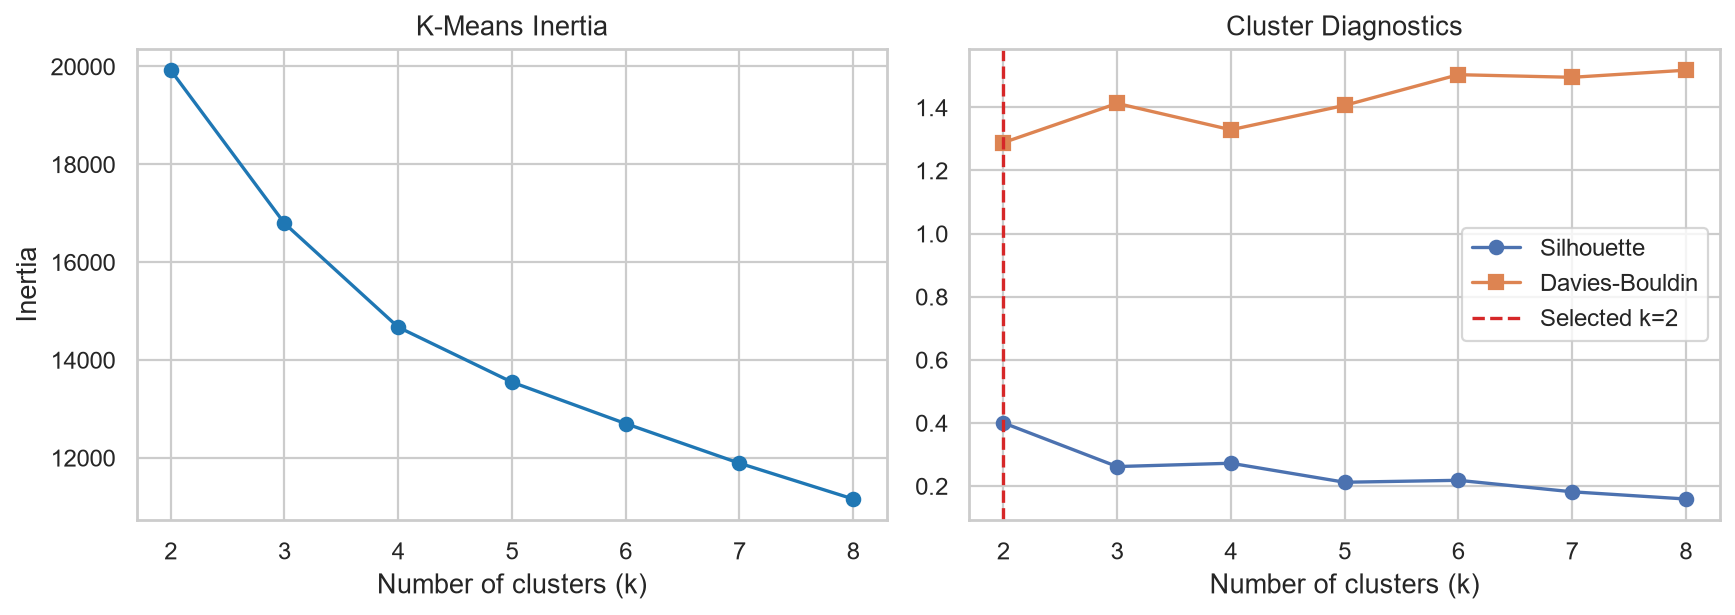

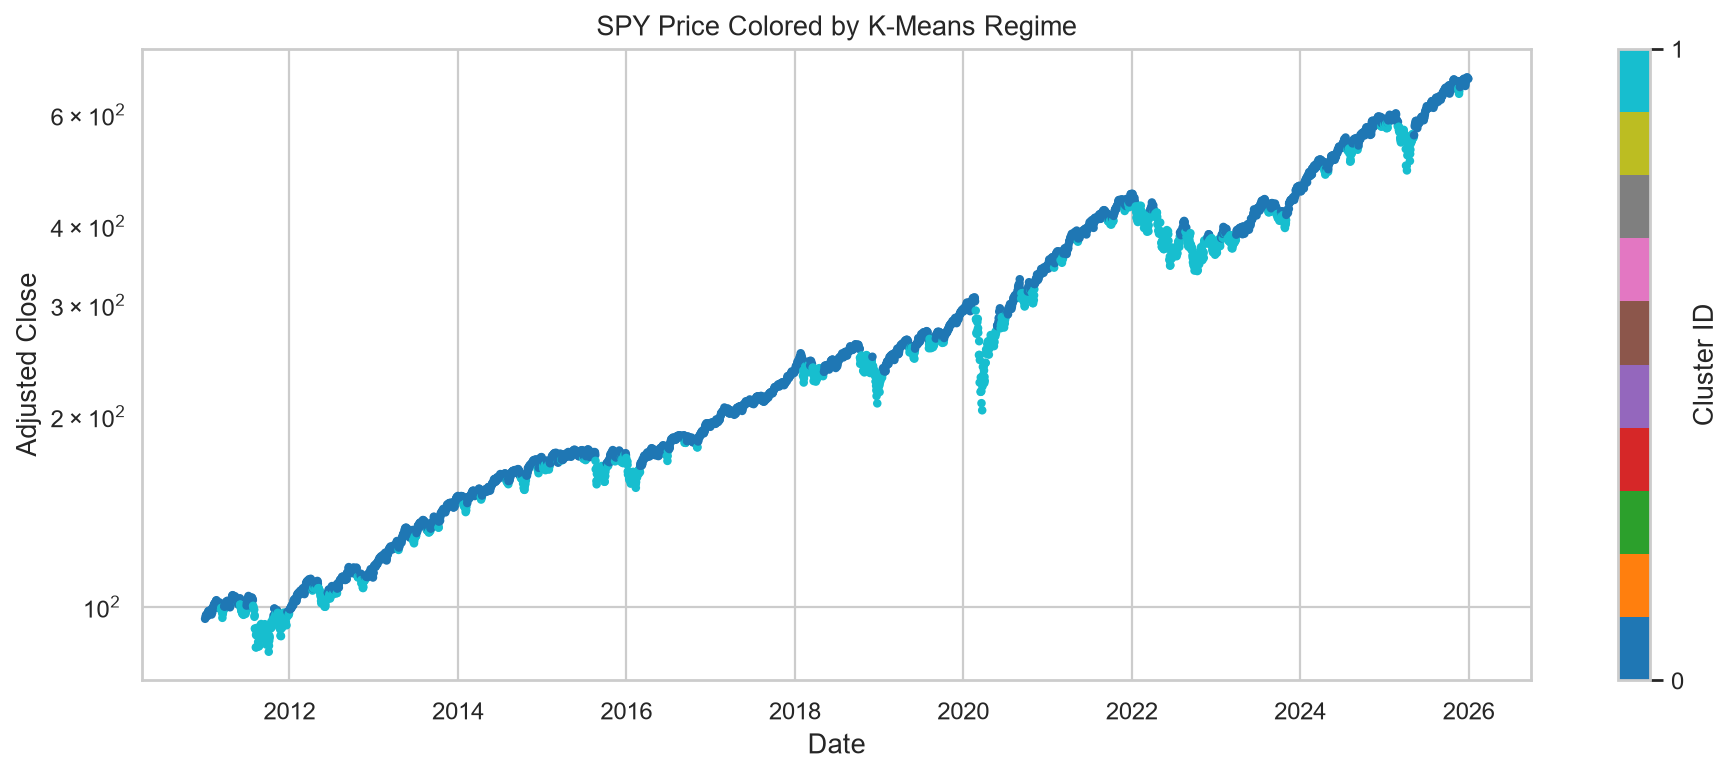

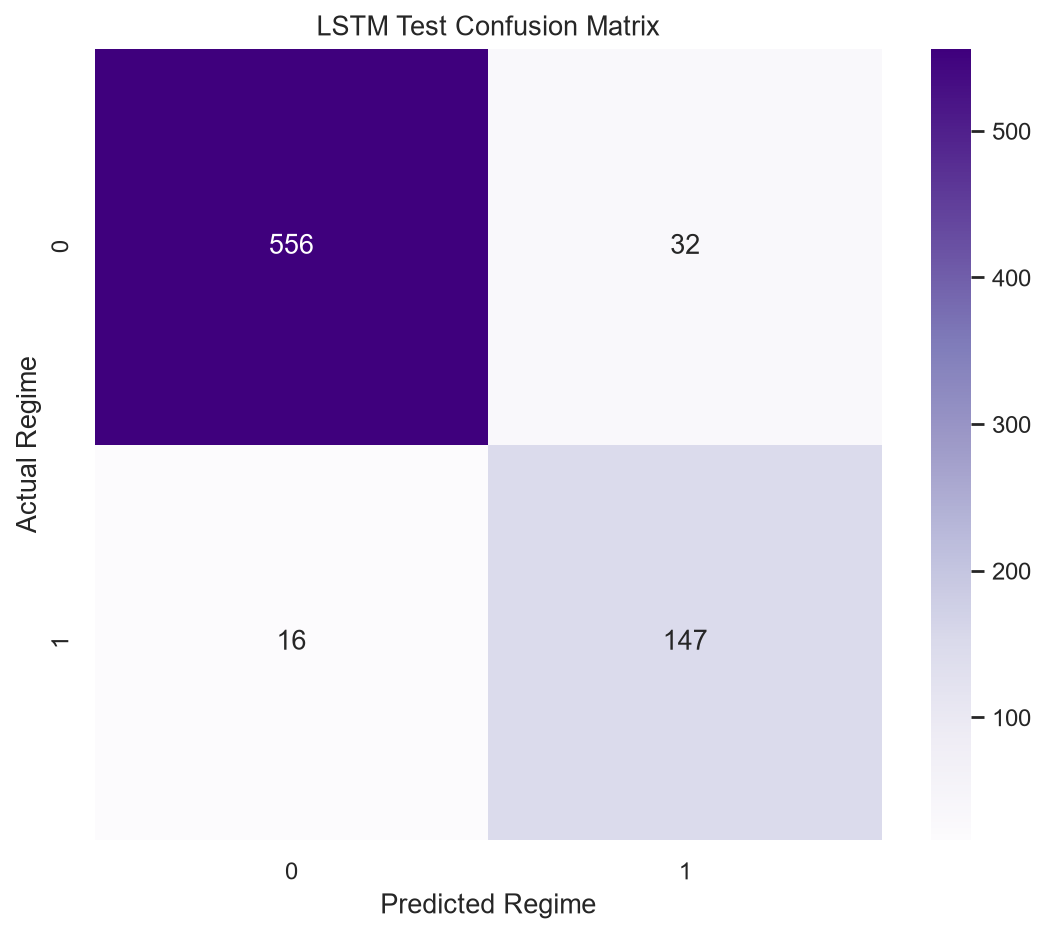

In [4]:
from IPython.display import Image, display

for figure in ['k_selection.png', 'regime_timeline.png', 'confusion_matrix.png']:
    display(Image(filename=str(PROJECT_ROOT / 'outputs' / 'figures' / figure)))